# Trích xuất các thư viện 

In [62]:
import pandas as pd
import numpy as np
from calendar import isleap
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import warnings

## 1.1 Đọc file M5

In [63]:
df_calendar = pd.read_csv('/Users/macos/Documents/MOIC_Inventory/ML Mr Hà/m5-forecasting-accuracy/calendar.csv')
# Contains the calendar dates on which date on the products are sold [d_1 - d_1941]
df_validation = pd.read_csv('/Users/macos/Documents/MOIC_Inventory/ML Mr Hà/m5-forecasting-accuracy/sales_train_validation.csv')
#Contains the historical daily unit sales data per product and store [d_1 - d_1913]
df_evaluation = pd.read_csv('/Users/macos/Documents/MOIC_Inventory/ML Mr Hà/m5-forecasting-accuracy/sales_train_evaluation.csv')
#Includes sales [d_1 - d_1941] (labels used for the Public leaderboard)
df_sell_prices = pd.read_csv('/Users/macos/Documents/MOIC_Inventory/ML Mr Hà/m5-forecasting-accuracy/sell_prices.csv')
# Contains the price of the products sold per store and date.

## Level 2: Unit sales of all products, aggregated for each state 

### Create a state columns

In [64]:
# Tạo bảng histical sell prices
#df_sell_prices['state_id'] = df_sell_prices['store_id'].str[:2]
#df_sell_prices = df_sell_prices[['store_id', 'state_id', 'item_id', 'wm_yr_wk', 'sell_price']]
#df_sell_prices
#df_sell_prices.groupby(['state_id', 'item_id']).size().agg({'sell_price': 'mean'}).reset_index()

### Croston forecast

In [65]:
# Thay các hàng dữ liệu d_1, d_2, ..., d_1941 bằng ngày tháng năm của bảng df_evaluation
old_columns = df_evaluation.columns[6:]  # ['col1', 'col2', 'col3']
new_columns = df_calendar['date'].tolist()  # ['col1', 'col2', 'col3']
rename_dict = dict(zip(old_columns, new_columns))
df_evaluation = df_evaluation.rename(columns=rename_dict)
# Inventory by state_id and item_id data_evaluation
df_evaluation = df_evaluation.groupby(['state_id', 'item_id','dept_id', 'cat_id']).sum().reset_index()
df_evaluation.drop(columns=['id', 'store_id'], inplace=True, errors='ignore')
df_evaluation

,state_id,item_id,dept_id,cat_id,2011-01-29,2011-01-30,2011-01-31,2011-02-01,2011-02-02,2011-02-03,...,2016-05-13,2016-05-14,2016-05-15,2016-05-16,2016-05-17,2016-05-18,2016-05-19,2016-05-20,2016-05-21,2016-05-22
0,CA,FOODS_1_001,FOODS_1,FOODS,6,3,2,3,7,5,...,5,5,3,1,1,2,2,4,4,2
1,CA,FOODS_1_002,FOODS_1,FOODS,3,3,4,4,3,3,...,3,4,6,2,1,2,0,4,4,4
2,CA,FOODS_1_003,FOODS_1,FOODS,9,4,3,4,2,5,...,4,3,4,8,8,5,3,3,4,4
3,CA,FOODS_1_004,FOODS_1,FOODS,0,0,0,0,0,0,...,30,35,15,20,15,24,13,17,26,37
4,CA,FOODS_1_005,FOODS_1,FOODS,23,13,6,15,7,8,...,10,8,13,4,2,5,11,21,7,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,WI,HOUSEHOLD_2_512,HOUSEHOLD_2,HOUSEHOLD,2,3,0,1,0,0,...,3,1,4,3,0,2,0,0,0,3
9143,WI,HOUSEHOLD_2_513,HOUSEHOLD_2,HOUSEHOLD,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
9144,WI,HOUSEHOLD_2_514,HOUSEHOLD_2,HOUSEHOLD,1,1,1,0,0,0,...,0,0,0,1,0,0,0,3,0,0
9145,WI,HOUSEHOLD_2_515,HOUSEHOLD_2,HOUSEHOLD,0,0,0,0,0,0,...,0,0,1,4,1,1,0,0,0,1


In [66]:
# Thay df_calendar bằng ngày tháng năm trong bảng df_validation
old_columns = df_validation.columns[6:]  # ['col1', 'col2', 'col3']
new_columns = df_calendar['date'].tolist()  # ['col1', 'col2', 'col3']
rename_dict = dict(zip(old_columns, new_columns))
df_validation = df_validation.rename(columns=rename_dict)
# Inventory by state_id and item_id data_validation
df_validation = df_validation.groupby(['state_id', 'item_id','dept_id', 'cat_id']).sum().reset_index()
df_validation.drop(columns=['id', 'store_id'], inplace=True, errors='ignore')
df_validation

,state_id,item_id,dept_id,cat_id,2011-01-29,2011-01-30,2011-01-31,2011-02-01,2011-02-02,2011-02-03,...,2016-04-15,2016-04-16,2016-04-17,2016-04-18,2016-04-19,2016-04-20,2016-04-21,2016-04-22,2016-04-23,2016-04-24
0,CA,FOODS_1_001,FOODS_1,FOODS,6,3,2,3,7,5,...,1,2,27,6,2,2,4,2,3,5
1,CA,FOODS_1_002,FOODS_1,FOODS,3,3,4,4,3,3,...,3,5,2,0,0,2,2,1,2,1
2,CA,FOODS_1_003,FOODS_1,FOODS,9,4,3,4,2,5,...,7,1,5,5,3,3,3,1,7,3
3,CA,FOODS_1_004,FOODS_1,FOODS,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CA,FOODS_1_005,FOODS_1,FOODS,23,13,6,15,7,8,...,10,8,4,4,8,10,3,9,25,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,WI,HOUSEHOLD_2_512,HOUSEHOLD_2,HOUSEHOLD,2,3,0,1,0,0,...,0,2,2,6,2,1,1,2,4,0
9143,WI,HOUSEHOLD_2_513,HOUSEHOLD_2,HOUSEHOLD,0,0,0,0,0,0,...,0,0,1,1,1,1,1,2,0,0
9144,WI,HOUSEHOLD_2_514,HOUSEHOLD_2,HOUSEHOLD,1,1,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
9145,WI,HOUSEHOLD_2_515,HOUSEHOLD_2,HOUSEHOLD,0,0,0,0,0,0,...,0,1,0,0,0,1,1,1,1,0


In [67]:
# Kiểm tra số lượng các giá trị khác 0 trong toàn bộ dataset
# Lấy các cột chứa dữ liệu về nhu cầu (demand)
# Các cột này thường bắt đầu từ d_1 đến d_1941
# Trong df_validation, các cột này bắt đầu từ cột thứ 5
# (cột 0-5 thường chứa các thông tin như state_id, item_id, dept_id, cat_id, v1, v2)
# Do đó, chúng ta sẽ lấy các cột từ cột thứ 5 trở đi

demand_cols_val = df_validation.columns[5:]
demand_cols_eval = df_evaluation.columns[5:]

# Đếm số lượng các giá trị khác 0 trong toàn bộ dataset
non_zero_total_val = (df_validation[demand_cols_val] != 0).count().count()
non_zero_total_eval = (df_evaluation[demand_cols_eval] != 0).count().count()

print(f"Tổng số giá trị khác 0 trong tập dữ liệu validation: {non_zero_total_val}")
print(f"Tổng số giá trị khác 0 trong tập dữ liệu evaluation: {non_zero_total_eval}")

Tổng số giá trị khác 0 trong tập dữ liệu validation: 1912
Tổng số giá trị khác 0 trong tập dữ liệu evaluation: 1940


In [ ]:
# Assume df_evaluation is already grouped at product–state level and date columns are after the first 4 columns
# Step 1: Identify date columns (assuming first 4 columns are IDs)
#date_columns = df_evaluation.columns[4:]

# Step 2: Count the number of days with non-zero sales for each series
#df_evaluation['non_zero_days'] = (df_evaluation[date_columns] > 0).sum(axis=1)

# Step 3: Filter for series with at least 730 days of non-zero sales
#df_filtered = df_evaluation[df_evaluation['non_zero_days'] >= 730].copy()

# Step 4: Drop the helper column if not needed
#df_filtered.drop(columns='non_zero_days', inplace=True)

# Step 5: Print results
#print(f"Total series before filtering: {len(df_evaluation)}")
#print(f"Total series after filtering (>= 730 days): {len(df_filtered)}")
#print(f"Series dropped: {len(df_evaluation) - len(df_filtered)}")

## Croston's forecasting methods
### Phương pháp này tách nhu cầu thành hai thành phần, cụ thể là:
### - Quy mô nhu cầu khác 0, 𝐷, 
### - Khoảng thời gian giữa các demand, 𝑇

#### * Calculate the ADI, CV in order to measure the Erratic Intermittent Lumpy Smooth 

In [113]:
def classify_demand(df):
    # 2. Tính toán các chỉ số ADI và CV^2 cho từng item
    result_validation = []

    # Lấy danh sách các cột ngày (chỉ lấy các cột kiểu số)
    date_columns = df.columns[5:]  # Sau 4 cột đầu là các cột ngày

    for item, group in df.groupby('item_id'):
        # Tính tổng nhu cầu theo ngày cho từng item (gộp các state nếu có)
        demand_series = group[date_columns].sum(axis=0).values

    # Đảm bảo dữ liệu là số
        demand_series = pd.to_numeric(demand_series, errors='coerce')
        n_periods = len(demand_series)
        non_zero_demands = demand_series[demand_series > 0]
        n_nonzero = len(non_zero_demands)

        if n_nonzero == 0:
            continue  # Bỏ qua nếu không có nhu cầu

    # ADI = số chu kỳ / số chu kỳ có nhu cầu
        adi = n_periods / n_nonzero # Chuyển đổi sang phần trăm

    # CV^2 = (std / mean)^2
        mean_demand = np.mean(non_zero_demands)
        std_demand = np.std(non_zero_demands, ddof=1)

        if mean_demand == 0:
            continue

        cv2 = (std_demand / mean_demand) ** 2  # Chuyển đổi sang phần trăm
        
        if adi <= 1.32 and cv2 <= 0.49:
            demand_type = 'smooth'
        elif adi > 1.32 and cv2 <= 0.49:
            demand_type = 'intermittent'
        elif adi <= 1.32 and cv2 > 0.49:
            demand_type = 'erratic'
        else:
            demand_type = 'lumpy'


        result_validation.append({
            "item_id": item,
            "ADI": adi,
            "CV2": cv2,
            "ln_ADI": np.log(adi),
            "ln_CV2": np.log(cv2),
            "Categories": demand_type
        })
    # Chuyển kết quả thành DataFrame
    result_validation = pd.DataFrame(result_validation)
    return result_validation

In [114]:
result_validation = classify_demand(df_validation)
result_evaluation = classify_demand(df_evaluation)
result_validation.head()

,item_id,ADI,CV2,ln_ADI,ln_CV2,Categories
0,FOODS_1_001,1.109438,0.449127,0.103854,-0.800449,smooth
1,FOODS_1_002,1.045281,0.310136,0.044286,-1.170745,smooth
2,FOODS_1_003,1.016446,0.309396,0.016312,-1.173134,smooth
3,FOODS_1_004,1.399562,0.203673,0.336159,-1.591241,intermittent
4,FOODS_1_005,1.304289,0.354478,0.265658,-1.037109,smooth


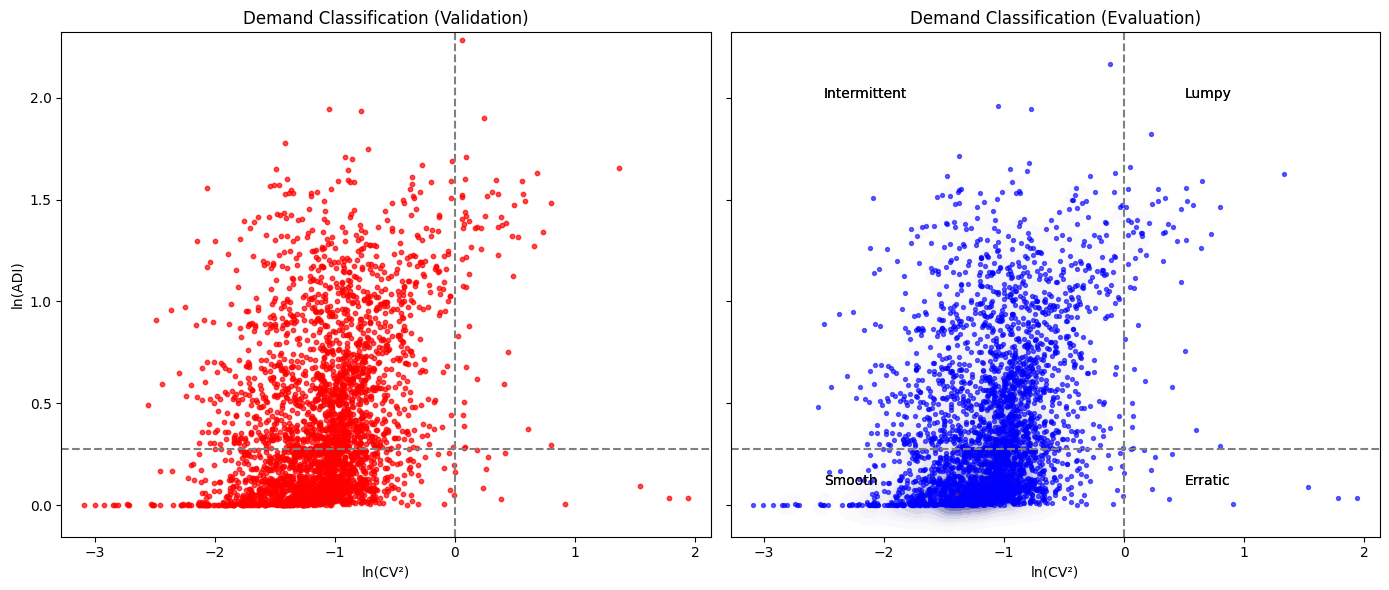

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Biểu đồ 1: Scatter Plot
axes[0].scatter(result_validation["ln_CV2"], result_validation["ln_ADI"], alpha=0.7, c="red", s=10)
axes[0].axvline(0, linestyle="--", color="gray")
axes[0].axhline(np.log(1.32), linestyle="--", color="gray")
axes[0].set_title("Demand Classification (Validation)")
axes[0].set_xlabel("ln(CV²)")
axes[0].set_ylabel("ln(ADI)")
# Thêm nhãn các vùng
plt.text(-2.5, 2, "Intermittent")
plt.text(0.5, 2, "Lumpy")
plt.text(-2.5, 0.1, "Smooth")
plt.text(0.5, 0.1, "Erratic")
plt.tight_layout()

# Biểu đồ 2: Density Plot + Scatter
sns.kdeplot(
    data=result_evaluation,
    x="ln_CV2", y="ln_ADI",
    fill=True, cmap="Purples", bw_adjust=0.5, thresh=0.05,
    ax=axes[1]
)
axes[1].scatter(result_evaluation["ln_CV2"], result_evaluation["ln_ADI"], s=8, alpha=0.6, c="blue")
axes[1].axvline(0, linestyle="--", color="gray")
axes[1].axhline(np.log(1.32), linestyle="--", color="gray")
axes[1].set_title("Demand Classification (Evaluation)")
axes[1].set_xlabel("ln(CV²)")
axes[1].set_ylabel("ln(ADI)")
# Thêm nhãn các vùng
plt.text(-2.5, 2, "Intermittent")
plt.text(0.5, 2, "Lumpy")
plt.text(-2.5, 0.1, "Smooth")
plt.text(0.5, 0.1, "Erratic")
plt.tight_layout()
plt.show()

In [70]:
# STEP 3: Classify demand types
def classify_demand(adi, cv2):
    if adi <= 1.32 and cv2 <= 0.49:
        return 'smooth'
    elif adi > 1.32 and cv2 <= 0.49:
        return 'intermittent'
    elif adi <= 1.32 and cv2 > 0.49:
        return 'erratic'
    else:
        return 'lumpy'

df_validation['category'] = df_validation.apply(lambda x: classify_demand(x['ADI'], x['CV2']), axis=1)
df_evaluation['category'] = df_evaluation.apply(lambda x: classify_demand(x['ADI'], x['CV2']), axis=1)
print(df_validation['category'].value_counts())
print(df_evaluation['category'].value_counts())

category
lumpy           6893
erratic         1569
smooth           684
intermittent       1
Name: count, dtype: int64
category
lumpy           6893
erratic         1569
smooth           684
intermittent       1
Name: count, dtype: int64


### Corston forecasting functions

In [71]:
def croston_forecast(series, alpha=0.1):
    """
    Implements Croston's method for intermittent demand forecasting.

    Args:
        series (list or array): The time series data.
        alpha (float): The smoothing parameter for exponential smoothing.

    Returns:
        float: The Croston's method forecast.
    """
    non_zero_demands = []
    inter_arrival_times = []
    last_demand_index = -1

    for i, demand in enumerate(series):
        if demand > 0:
            non_zero_demands.append(demand)
            if last_demand_index != -1:
                inter_arrival_times.append(i - last_demand_index)
            last_demand_index = i

    if not non_zero_demands:
        return 0  # No demand observed

    # Handle cases with very few non-zero demands
    if len(non_zero_demands) < 2:
        smoothed_demand = non_zero_demands[0]
        smoothed_interval = np.mean(inter_arrival_times) if inter_arrival_times else 1
    else:
        # Simple Exponential Smoothing for non-zero demands
        smoothed_demand = non_zero_demands[0]
        for val in non_zero_demands[1:]:
            smoothed_demand = alpha * val + (1 - alpha) * smoothed_demand

        # Simple Exponential Smoothing for inter-arrival times
        smoothed_interval = inter_arrival_times[0] if inter_arrival_times else 1
        if len(inter_arrival_times) > 1:
            for val in inter_arrival_times[1:]:
                smoothed_interval = alpha * val + (1 - alpha) * smoothed_interval

    return smoothed_demand / smoothed_interval

# Example Usage
data = [0, 0, 5, 0, 0, 0, 10, 0, 0, 0, 0, 8]
forecast = croston_forecast(data)
print(f"Croston's Forecast: {forecast:.2f}")

Croston's Forecast: 1.40


In [72]:
# Forecast data for validation set
results_val = {}
for i, row in df_validation.iterrows():
    series = row[demand_cols_val].values
    forecast = croston_forecast(series)
    results_val[row['item_id']] = forecast

# Forecast data for evaluation set
results_eval = {}
for i, row in df_evaluation.iterrows():
    series = row[demand_cols_eval].values
    forecast = croston_forecast(series)
    results_eval[row['item_id']] = forecast

# Convert results to DataFrame for better visualization
results_df_val = pd.DataFrame(list(results_val.items()), columns=['item_id', 'croston_forecast'])
results_df_eval = pd.DataFrame(list(results_eval.items()), columns=['item_id', 'croston_forecast_eval'])
print(results_df_val.head())
print(results_df_eval.head())


       item_id  croston_forecast
0  FOODS_1_001          1.476003
1  FOODS_1_002          1.675802
2  FOODS_1_003          1.163348
3  FOODS_1_004         25.713047
4  FOODS_1_005          6.494327
       item_id  croston_forecast_eval
0  FOODS_1_001               1.498569
1  FOODS_1_002               1.403075
2  FOODS_1_003               1.887738
3  FOODS_1_004              25.193304
4  FOODS_1_005               4.552048


### ADI , CV^2, Di: Average demand of product 𝑖 over 𝑇 periods
### 
The method separates demand into two components, namely the non-zero demand size, 𝐷, and the inter-demand
intervals, 𝑇, and extrapolates them individually using simple exponential smoothing (Gardner, 1985). Both components are forecasted using
a smoothing parameter of 0.1 and an initial state value equal to the
first observation of each component, as follows:

# LightGBM model 

## Training data

In [ ]:
features = ['ADI', 'CV2', 'mu']
label_encoder = LabelEncoder()
df_validation['category_encoded'] = label_encoder.fit_transform(df_validation['category'])

X = df_validation[features]
y = df_validation['category_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'verbose': -1
}

In [ ]:
model = lgb.train(
	params,
	train_data,
	valid_sets=[valid_data],
	num_boost_round=1000,
	callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's multi_logloss: 0.00719456


In [ ]:
# STEP 5: Evaluate
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Ensure all possible classes are included in the report
all_labels = np.arange(len(label_encoder.classes_))
print(classification_report(
	y_test, y_pred_labels,
	labels=all_labels,
	target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

     erratic       1.00      0.99      1.00       297
intermittent       0.00      0.00      0.00         0
       lumpy       1.00      1.00      1.00      1411
      smooth       0.98      1.00      0.99       122

    accuracy                           1.00      1830
   macro avg       0.75      0.75      0.75      1830
weighted avg       1.00      1.00      1.00      1830



# Visualize the result

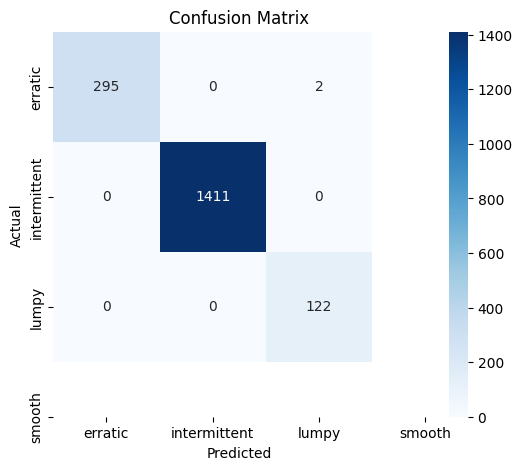

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_labels)
class_names = label_encoder.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()